In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing


In [2]:
data = fetch_california_housing()

In [3]:
df = pd.DataFrame(data = data.data , columns = data.feature_names)


In [4]:
df['Price'] = data.target

In [5]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
df.shape

(20640, 9)

In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

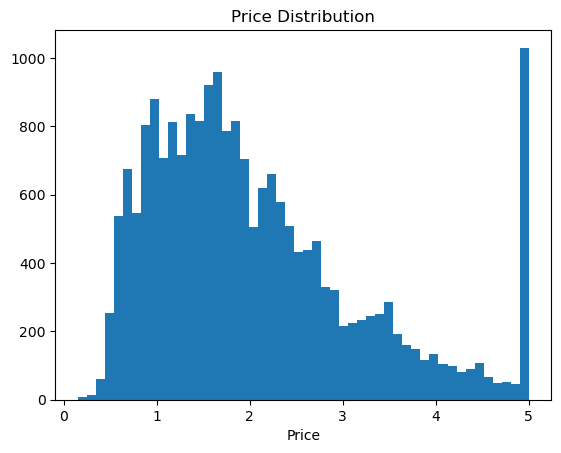

In [9]:
plt.hist(df['Price'],bins=50)
plt.xlabel('Price')
plt.title('Price Distribution')
plt.show()


Observation 1: Most house prices are concentrated between $100k-$300k
Observation 2: Distribution is right-skewed — more cheap houses than expensive ones
Observation 3: There is an artificial cap at $500k — houses above this price 
were all recorded as 5.0, which may affect model accuracy

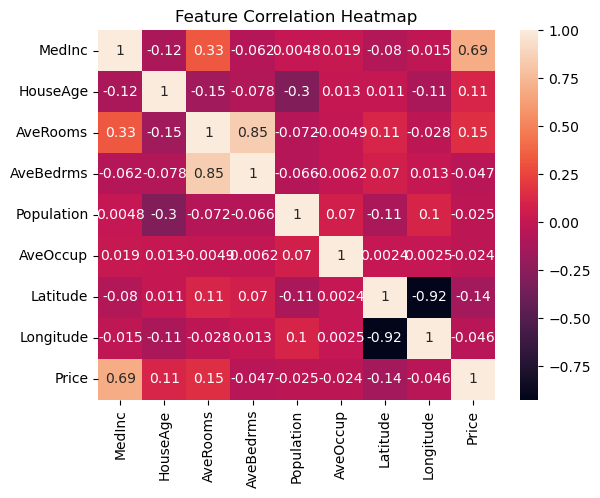

In [10]:
sns.heatmap(df.corr(),annot=True)
plt.title('Feature Correlation Heatmap')
plt.show()

Observation 4: MedInc has highest correlation with Price (0.69) — 
richer neighborhoods have more expensive houses. Makes sense.

Observation 5: Latitude and Longitude have low correlation with Price 
individually but location still matters — we'll keep them.

Observation 6: AveRooms and AveBedrms are highly correlated with each other.
This is called multicollinearity. They carry similar information.

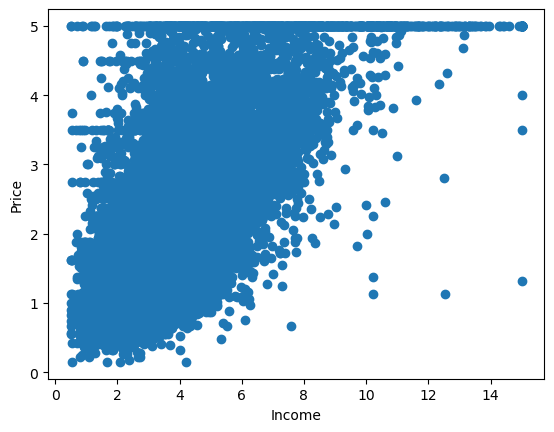

In [11]:
plt.scatter(x=df['MedInc'] , y=df['Price'])
plt.xlabel('Income')
plt.ylabel('Price')
plt.show()

Observation 7: Clear positive relationship between MedInc and Price.
Higher income neighborhoods = more expensive houses.
The flat line at Price=5.0 confirms the artificial price cap we noticed earlier.

<function matplotlib.pyplot.show(close=None, block=None)>

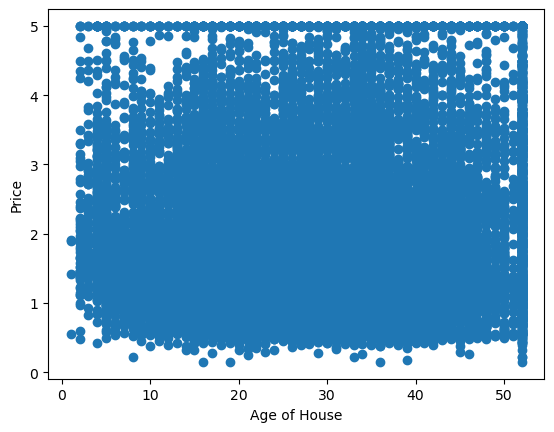

In [12]:
plt.scatter(x=df['HouseAge'] , y=df['Price'])
plt.xlabel('Age of House')
plt.ylabel('Price')
plt.show

Observation 8: House age has very weak relationship with Price.
Age alone is not a good predictor of house price.
MedInc is clearly the most important feature so far.

In [13]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2 , random_state = 20)

In [16]:
X_train.shape

(16512, 8)

In [17]:
y_train.shape

(16512,)

In [18]:
X_test.shape

(4128, 8)

In [19]:
import os
print(os.getcwd())

C:\Users\rajpu\PUNISHER
